# 01 Text Preprocessing

## 📚 Learning Objectives

By completing this notebook, you will:
- Clean and normalize text (lowercasing, punctuation, whitespace)
- Use basic preprocessing pipelines for NLP
- Prepare text for downstream tasks

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 2, lesson 08 "Feature Extraction from Unstructured Data" — cleaning is still the first step; here the messy column is language rather than numbers.

**Used later in:** Course 07 — Unit 2, which tokenises the normalised text, and Unit 3, which turns it into TF-IDF features.

---


## 🌍 Why this matters: the town that could not sign up for email

In 1996 AOL put a profanity filter on its sign-up form. The filter matched offensive strings *anywhere
inside* a word, so residents of **Scunthorpe** — a real town in North Lincolnshire, England — could not
create an account: the town's name contains a four-letter obscenity as a substring, and the address field
was mandatory. The contemporaneous report (Clive Feather, *The Risks Digest* 18.07, 25 April 1996,
<https://catless.ncl.ac.uk/Risks/18.07.html>) records AOL's stop-gap: residents could register only by
entering the town as "Sconthorpe". The bug is famous enough to have a name — the **Scunthorpe problem** —
and the same substring failure keeps catching other English place names in later filters: residents of
**Penistone** have had e-mail blocked, and residents of **Clitheroe** have been repeatedly inconvenienced,
for exactly the same reason.

**What goes wrong without this lesson.** Nobody at AOL decided to block a town. Somebody wrote one line of
text processing — *match this string, lowercase, no word boundaries* — and shipped it. Every preprocessing
choice you make below (lowercase? strip punctuation? drop stop words?) is a decision of exactly that kind:
invisible in the code, loud in production. The purpose of this notebook is to make you look at what each
step does to the text **before** you trust it.

**The same failure in other domains:** clinical NLP needs a dedicated negation algorithm — NegEx (Chapman
et al., *J. Biomedical Informatics* 34(5), 2001) and its 35 negation phrases — precisely because a generic
pipeline that drops "no" and "not" as stop words turns *"no evidence of tumour"* into *"evidence of
tumour"*; a bank's transaction cleaner that strips Arabic diacritics can merge two different customers into
one; a résumé parser that lowercases everything cannot tell the profession "IT" from the pronoun "it".

## 📥 Inputs & 📤 Outputs

**Inputs:** a short 3-sentence paragraph about NLP, defined directly in the code cell (no downloads), plus Python's `re`, `string`, `collections.Counter`, and Matplotlib.

**Outputs:** the token list, the punctuation-free text, the tokens after stop-word removal, a word-frequency table, a chart comparing the naive counts against punctuation-aware counts, and a four-step storyboard of
the same 26 tokens — all computed live from that paragraph.

---

Example 1: Text Preprocessing

Original Text:

Natural Language Processing (NLP) is a branch of artificial intelligence
that helps computers understand, interpret, and manipulate human language.
NLP combines computational linguistics with machine learning.


1. Tokenization

Tokens: ['natural', 'language', 'processing', '(nlp)', 'is', 'a', 'branch', 'of', 'artificial', 'intelligence', 'that', 'helps', 'computers', 'understand,', 'interpret,', 'and', 'manipulate', 'human', 'language.', 'nlp', 'combines', 'computational', 'linguistics', 'with', 'machine', 'learning.']
Number of tokens: 26

2. Remove Punctuation

Cleaned text:

Natural Language Processing NLP is a branch of artificial intelligence
that helps computers understand interpret and manipulate human language
NLP combines computational linguistics with machine learning


3. Stop Word Removal

Tokens after stop word removal: ['natural', 'language', 'processing', '(nlp)', 'branch', 'of', 'artificial', 'intelligence', 'helps', 'comp

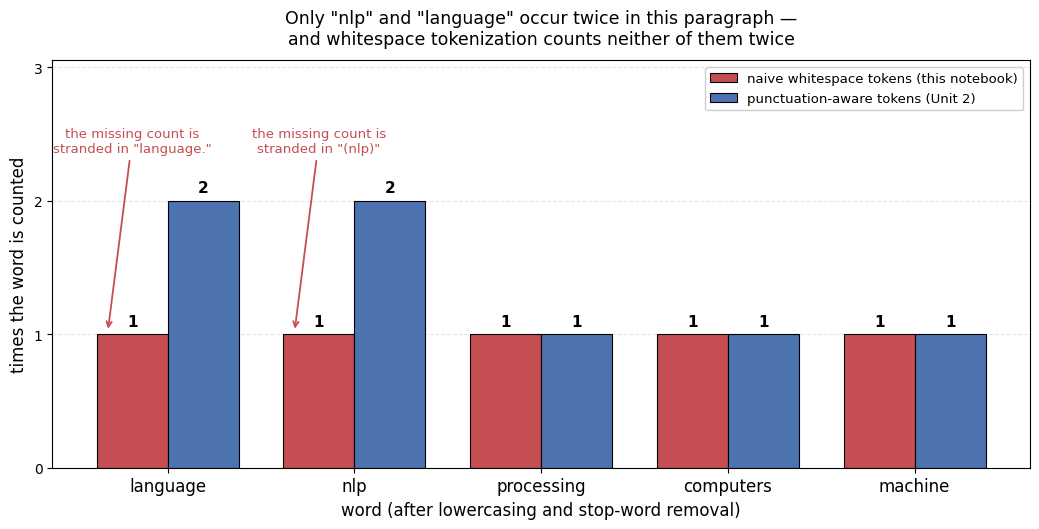

In [1]:
# Worked example: a complete miniature text-preprocessing pipeline on one paragraph.
# Why it matters: every NLP system starts here — raw text must become clean tokens
# before any model can count, embed, or classify it. Watch each step change the text.

"""
Unit 1 - Example 1: Text Preprocessing

This example demonstrates:
1. Simple whitespace tokenization
2. Punctuation removal (text normalization)
3. Stop word removal
4. Word frequency analysis with a bar chart
"""

import re
import string
from collections import Counter

print("=" * 60)
print("Example 1: Text Preprocessing")
print("=" * 60)

# Sample text
sample_text = """
Natural Language Processing (NLP) is a branch of artificial intelligence
that helps computers understand, interpret, and manipulate human language.
NLP combines computational linguistics with machine learning.
"""

print("\nOriginal Text:")
print(sample_text)

# 1. Tokenization
print("\n" + "=" * 60)
print("1. Tokenization")
print("=" * 60)

def simple_tokenize(text):
    """
    Simple tokenization by splitting on whitespace.
    """
    # Remove extra whitespace and split
    tokens = text.lower().split()
    return tokens

tokens = simple_tokenize(sample_text)
print(f"\nTokens: {tokens}")
print(f"Number of tokens: {len(tokens)}")

# 2. Remove Punctuation
print("\n" + "=" * 60)
print("2. Remove Punctuation")
print("=" * 60)

def remove_punctuation(text):
    """
    Remove punctuation from text.
    """
    return text.translate(str.maketrans('', '', string.punctuation))

cleaned_text = remove_punctuation(sample_text)
print(f"\nCleaned text:\n{cleaned_text}")

# 3. Stop Word Removal
print("\n" + "=" * 60)
print("3. Stop Word Removal")
print("=" * 60)

# Common English stop words
stop_words = {'is', 'a', 'the', 'that', 'this', 'with', 'and', 'or', 'but'}

def remove_stop_words(tokens, stop_words):
    """
    Remove stop words from tokens.
    """
    return [token for token in tokens if token not in stop_words]

filtered_tokens = remove_stop_words(tokens, stop_words)
print(f"\nTokens after stop word removal: {filtered_tokens}")

# 4. Word Frequency
print("\n" + "=" * 60)
print("4. Word Frequency Analysis")
print("=" * 60)

word_freq = Counter(filtered_tokens)
print("\nWord Frequencies:")
for word, freq in word_freq.most_common():
    print(f"  {word}: {freq}")

print("\n" + "=" * 60)
print("Example completed successfully!")
print("=" * 60)

# ---------------------------------------------------------------------------
# FIGURE 1 - the claim this lesson has to prove with a picture.
# WHAT: compare, word by word, how many times the naive whitespace pipeline
#       counted a word against how many times it actually occurs once
#       punctuation is stripped from each token.
# WHY:  the frequency table printed above gives every word a count of 1, which
#       looks like "no word repeats". That is false, and a chart of ten equal
#       bars would hide it. This chart makes the lost counts visible.
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt

# Same tokens, but punctuation removed from each token BEFORE counting.
# (Above, remove_punctuation was applied to the raw text, not to the token list.)
aware_tokens = [remove_punctuation(t) for t in tokens]
aware_tokens = [t for t in aware_tokens if t and t not in stop_words]
aware_freq = Counter(aware_tokens)

# Which words genuinely occur more than once in this paragraph?
repeated = sorted([w for w, c in aware_freq.items() if c > 1])
controls = [w for w in ("processing", "computers", "machine") if aware_freq[w] == 1]
show = repeated + controls

naive_counts = [word_freq[w] for w in show]          # what this notebook counted
aware_counts = [aware_freq[w] for w in show]         # what is actually there

# For each repeated word, find the surface form that stole the missing count.
stranded = {w: sorted(t for t in set(tokens)
                      if remove_punctuation(t) == w and t != w)
            for w in repeated}

print("\nWords that really occur more than once:", repeated)
for w in repeated:
    print(f"  {w!r}: naive count = {word_freq[w]}, true count = {aware_freq[w]}, "
          f"missing count stranded in {stranded[w]}")
print(f"\nVocabulary size — naive: {len(word_freq)} types, "
      f"punctuation-aware: {len(aware_freq)} types")

fig, ax = plt.subplots(figsize=(10.5, 5.4))
xs = range(len(show))
bw = 0.38
bars_naive = ax.bar([i - bw / 2 for i in xs], naive_counts, bw, color="#c44e52",
                    edgecolor="black", linewidth=0.8,
                    label="naive whitespace tokens (this notebook)")
bars_aware = ax.bar([i + bw / 2 for i in xs], aware_counts, bw, color="#4c72b0",
                    edgecolor="black", linewidth=0.8,
                    label="punctuation-aware tokens (Unit 2)")
for bar, v in list(zip(bars_naive, naive_counts)) + list(zip(bars_aware, aware_counts)):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.04, str(v),
            ha="center", va="bottom", fontsize=11, fontweight="bold")
for i, wd in enumerate(show):
    if stranded.get(wd):
        ax.annotate(f'the missing count is\nstranded in "{stranded[wd][0]}"',
                    xy=(i - bw / 2 - 0.13, 1.02), xytext=(i - bw / 2, 2.34),
                    ha="center", va="bottom", fontsize=9.5, color="#c44e52",
                    arrowprops=dict(arrowstyle="->", color="#c44e52", lw=1.3))
ax.set_xticks(list(xs))
ax.set_xticklabels(show, fontsize=12)
ax.set_xlabel("word (after lowercasing and stop-word removal)", fontsize=12)
ax.set_ylabel("times the word is counted", fontsize=12)
ax.set_title('Only "nlp" and "language" occur twice in this paragraph —\n'
             "and whitespace tokenization counts neither of them twice",
             fontsize=12.5, pad=12)
ax.set_ylim(0, 3.05)
ax.set_yticks([0, 1, 2, 3])
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)
ax.legend(loc="upper right", fontsize=9.5, framealpha=0.95)
plt.tight_layout()
plt.show()


**Read the chart above.** Two bars per word, five words.

- On `processing`, `computers` and `machine` the red and blue bars are the same height — the two pipelines
  agree, and nothing is lost.
- On `nlp` and `language` they disagree: the blue bar reaches **2**, the red bar stops at **1**. The arrows
  name where the missing count went — into the separate tokens `(nlp)` and `language.`, which the naive
  splitter never joined to their bare forms.

So the flat frequency table above is not telling you "nothing repeats in this paragraph". It is telling you
that **your tokenizer cannot see repetition through a bracket or a full stop.** In a search index that is a
document you will never retrieve; in the Scunthorpe filter it was a town that could not sign up.


stage                                   tokens  distinct types
--------------------------------------------------------------
1. raw whitespace split                     26              26
2. lowercased                               26              26
3. stop-words removed                       21              21
4. punctuation stripped per token           21              19


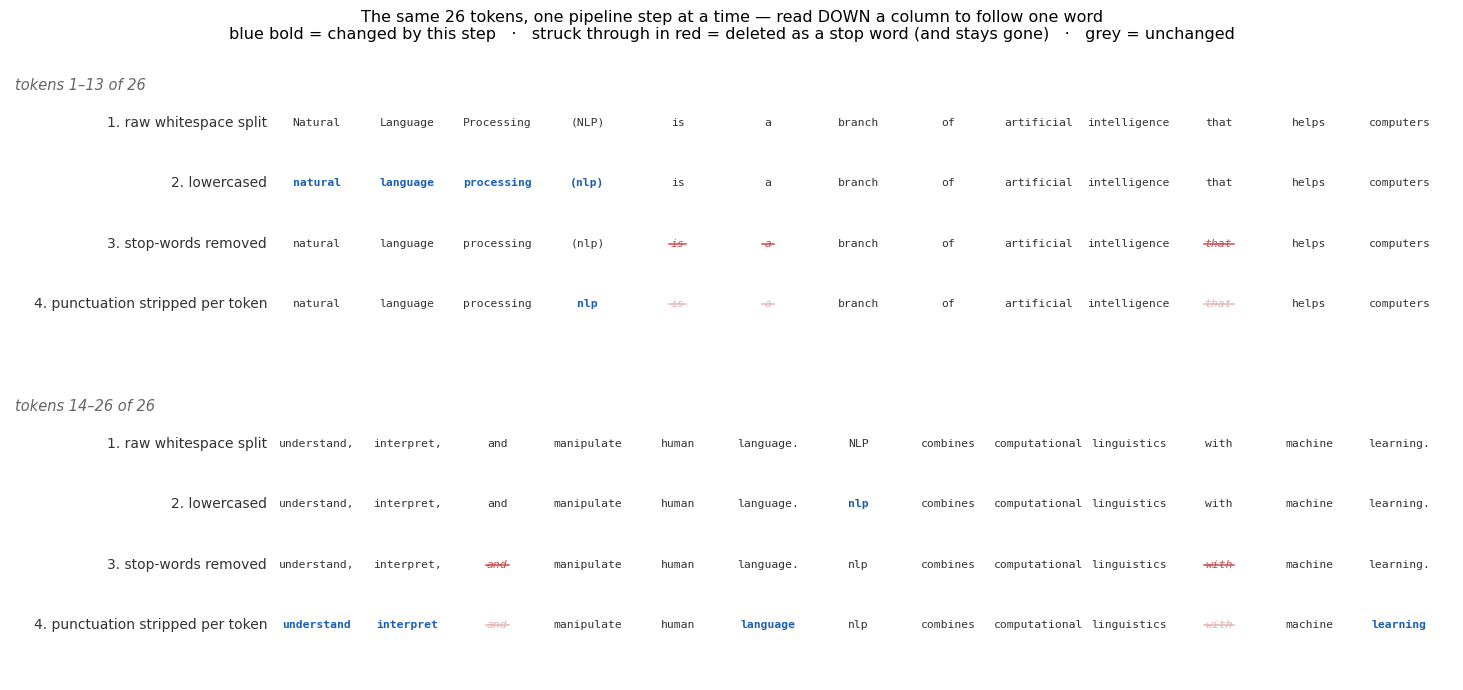

In [2]:
# ---------------------------------------------------------------------------
# FIGURE 2 - the pipeline as a storyboard (a static frame grid, one row per step).
# WHAT: the SAME 26 tokens shown four times, once after each stage, so you can
#       read down a column and watch a single word travel through the pipeline.
# WHY:  preprocessing is a sequence of destructive edits. Printed lists show the
#       end state; only a step-by-step grid shows WHICH word each step changed
#       or deleted - which is the decision you are actually being asked to audit.
# Cost note: pure text drawing, no data generation - renders in well under a second.
# ---------------------------------------------------------------------------
raw_tokens = sample_text.split()                       # original case, 26 tokens
low_tokens = [t.lower() for t in raw_tokens]           # step 1 of simple_tokenize
keep = [t not in stop_words for t in low_tokens]       # stop-word decision per token
nostop = [t if k else "" for t, k in zip(low_tokens, keep)]
nopunct = [remove_punctuation(t) if k else "" for t, k in zip(low_tokens, keep)]

stages = [("1. raw whitespace split", raw_tokens),
          ("2. lowercased", low_tokens),
          ("3. stop-words removed", nostop),
          ("4. punctuation stripped per token", nopunct)]

# The printed step table that goes with the storyboard.
print(f"{'stage':38s} {'tokens':>7s} {'distinct types':>15s}")
print("-" * 62)
for name, seq in stages:
    live = [t for t in seq if t]
    print(f"{name:38s} {len(live):7d} {len(set(live)):15d}")

N, PER_ROW = len(raw_tokens), 13
CHAR_W = 0.066                       # data units per monospace character at size 8.2
fig, ax = plt.subplots(figsize=(15.0, 7.0))
y_last = 0.0
for block, cols in enumerate([list(range(0, PER_ROW)), list(range(PER_ROW, N))]):
    for si, (label, seq) in enumerate(stages):
        y = -(block * (len(stages) + 1.3) + si)
        y_last = y
        if si == 0:
            ax.text(-3.35, y + 0.62, f"tokens {cols[0] + 1}–{cols[-1] + 1} of {N}",
                    ha="left", va="center", fontsize=10.5, color="#666666", style="italic")
        ax.text(-0.55, y, label, ha="right", va="center", fontsize=10, color="#333333")
        for ci, ti in enumerate(cols):
            text = seq[ti]
            prev = stages[si - 1][1][ti] if si > 0 else None
            gone = (text == "")
            shown = low_tokens[ti] if gone else text
            if gone:                                   # deleted as a stop word
                colour = "#c44e52" if si == 2 else "#e0b6b6"
                weight, style = "normal", "italic"
            else:                                      # changed by this step, or unchanged
                colour = "#1a5fb4" if (prev is not None and prev != text) else "#333333"
                weight = "bold" if colour == "#1a5fb4" else "normal"
                style = "normal"
            ax.text(ci, y, shown, ha="center", va="center", fontsize=8.2,
                    family="DejaVu Sans Mono", color=colour, style=style, fontweight=weight)
            if gone:                                   # draw the strike-through
                half = len(shown) * CHAR_W / 2 + 0.03
                ax.plot([ci - half, ci + half], [y, y], color=colour, lw=1.1, zorder=3)
ax.set_xlim(-3.4, PER_ROW - 0.4)
ax.set_ylim(y_last - 0.9, 1.1)
ax.axis("off")
ax.set_title("The same 26 tokens, one pipeline step at a time — read DOWN a column to follow one word\n"
             "blue bold = changed by this step   ·   struck through in red = deleted as a stop word "
             "(and stays gone)   ·   grey = unchanged",
             fontsize=11.5, pad=12)
plt.tight_layout()
plt.show()


**Read the storyboard above.** Four rows = the four steps; each column is one token, held in the same
place all the way down, so a column is one word's whole journey.

- **Column 4** starts as `(NLP)`, turns blue at step 2 (lowercased to `(nlp)`), survives step 3, and turns
  blue again at step 4 when the brackets come off and it finally becomes `nlp` — the same word as column 20.
  That is the count-splitting from Figure 1, drawn one step at a time.
- **The five red strike-throughs** — `is`, `a`, `that`, `and`, `with` — are the words the nine-item stop
  list deleted. They stay struck (faded) in row 4 because nothing brings a deleted token back. Cover the
  remaining words with your hand and ask whether the paragraph still means what it meant.
- **Grey columns never move.** `branch`, `human`, `combines`, `machine` pass through all four steps
  untouched — most of the vocabulary is unaffected, which is exactly why the damage at the edges is easy
  to miss.

**One honest caveat about row 4.** The code above applied `remove_punctuation` to the *raw text string*,
not to the token list — so the token list this notebook actually counted still contains `(nlp)` and
`language.`. Row 4 shows what the same function does when applied *per token*, which is the repair Unit 2
makes properly. The step table printed above the picture is the arithmetic of the same thing: 26 tokens in,
21 after the stop list, and the vocabulary only drops from 21 distinct types to 19 once punctuation is
handled at the token level — those two merges are `nlp` and `language`.


## 💬 Discuss

Argue these from the output above, not from general principles.

1. The frequency table gives every word a count of 1, and `language` and `language.` were counted as two
   different words. Now imagine this pipeline feeding a search box on a Saudi government portal. Which is
   the more expensive failure — the split counts, or a stop-word list that quietly deletes the one word a
   citizen actually searched for? Defend your choice using the printed output.
2. Our stop-word set is nine hand-picked English words. Name two words you would **add** for this paragraph
   and two you would **refuse** to remove no matter what any list says. What rule are you actually using?
3. `str.translate` deleted every punctuation mark in the text. Name one document type where that is
   destructive — think prices, dates, IBANs, phone numbers, hashtags, Arabic diacritics. Would you rather
   over-clean and lose information, or under-clean and let noise into the model? Who pays for each mistake,
   and would they ever find out?

---

## ✅ Summary

**What you actually did here** (check each claim against the printed output above):

- Tokenized the paragraph by whitespace into 26 lowercase tokens
- Removed punctuation with `str.translate`, and filtered a small hardcoded stop-word set
- Counted word frequencies with `Counter`, then plotted the naive counts against
  punctuation-aware counts, and drew the four preprocessing steps as a token storyboard

**Read the output critically — it teaches the next lesson:** every frequency in this run is 1, and the
naive whitespace tokenizer left `(nlp)` and `language.` as tokens separate from `nlp` and `language`,
splitting their counts. Proper tokenization (Unit 2) fixes exactly this.

**Next steps:**
- Complete `exercises/01_text_preprocessing_exercise.ipynb`
- Proceed to Unit 2 for real tokenization and morphology

## ⚠️ Where this breaks

Everything above rests on one assumption: **meaning survives normalization.** Often it does not.

| Step | Breaks when | Cheaper / safer alternative |
|---|---|---|
| Lowercasing | case carries meaning: `US` vs `us`, `Apple` vs `apple`, `IT` vs `it` | lowercase only for the counting step and keep the original text for display and for NER |
| Punctuation stripping | numbers, prices, dates, URLs, IBANs, hashtags, source code | tokenize first with a type-aware tokenizer, then decide per token type |
| Stop-word removal | short queries and phrases built entirely out of common words | do not use a stop list at all — see below |
| Whitespace tokenization | languages that do not delimit words with spaces (Chinese, Thai), and Arabic clitics (`و`, `ال`, `ب`, `ل`) glued to the next word | subword tokenization — Unit 2 |

**On stop words specifically.** Manning, Raghavan & Schütze's *Introduction to Information Retrieval*
(2008, §2.2.2, <https://nlp.stanford.edu/IR-book/>) points out that queries such as *"President of the
United States"* and *"flights to London"* lose their meaning once the function words are dropped, and
states plainly that **web search engines generally do not use stop lists** — compression and term weighting
handle common words better than deletion ever did. The `stop_words` set here is a teaching device, not a
production default.

**When this is the wrong lesson entirely.** In 2026 much of what arrives as "raw text" is not text: it is
scanned PDFs, invoices and forms, where the hard problems are reading order and table structure, not
punctuation. Those are now handled by small vision-language document parsers such as SmolDocling
([arXiv:2503.11576](https://arxiv.org/abs/2503.11576)) and MinerU2.5
([arXiv:2509.22186](https://arxiv.org/abs/2509.22186)). Regex cleaning is step two of that pipeline, not
step one.

## 🔭 State of the field (2026)

The five steps you just ran are still the mechanism, but in 2026 they are rarely the *first* step and almost
never the whole step. A production text pipeline now begins one stage earlier, with a vision-language
document parser that turns a PDF or a scan into structured text with reading order and tables intact —
MinerU2.5 does exactly that ([arXiv:2509.22186](https://arxiv.org/abs/2509.22186)) — and what follows the
parser is much lighter than this notebook: Unicode normalization, de-duplication and quality filtering, then
a subword tokenizer (Unit 2) that absorbs case and morphology on its own, so stemming and stop lists are
usually *omitted* rather than tuned. Aggressive normalization does survive in one place you will meet
constantly: the lexical (BM25/TF-IDF) half of a retrieval system, where matching the exact surface form
decides whether a document is found at all — while the other half is handled by instruction-tuned
multilingual embedding models ([arXiv:2506.05176](https://arxiv.org/abs/2506.05176)).

Learn it here anyway, and learn it in this order. Every one of those 2026 stages is a decision about *what
to destroy*, which is the decision you just made five times by hand, and you cannot audit a tokenizer, a
de-duplication rule or a BM25 index without knowing what normalization removes. This lesson is also the
version the course assesses: a counted, inspectable pipeline you can explain line by line.


## 📚 References

Where these ideas come from — seminal work first, then a modern survey, then where this stage sits in a 2026 pipeline:

1. Porter, M. F. (1980). *An Algorithm for Suffix Stripping*. Program, 14(3), 130-137.
2. Jurafsky, D. & Martin, J. H. (2025). *Speech and Language Processing* (3rd ed. draft) — chapter on text normalization, tokenization, and edit distance. <https://web.stanford.edu/~jurafsky/slp3/>
3. Mielke, S. J., Alyafeai, Z., Salesky, E., et al. (2021). *Between Words and Characters: A Brief History of Open-Vocabulary Modeling and Tokenization in NLP*. [arXiv:2112.10508](https://arxiv.org/abs/2112.10508)
4. Nassar, A., Marafioti, A., Omenetti, M., Lysak, M., Livathinos, N., et al. (2025). *SmolDocling: An ultra-compact vision-language model for end-to-end multi-modal document conversion*. [arXiv:2503.11576](https://arxiv.org/abs/2503.11576) — a 256M-parameter model that produces structured document output; the stage that now runs *before* the cleaning you did here.
5. Niu, J., Liu, Z., Gu, Z., Wang, B., Ouyang, L., et al. (2025). *MinerU2.5: A Decoupled Vision-Language Model for Efficient High-Resolution Document Parsing*. [arXiv:2509.22186](https://arxiv.org/abs/2509.22186) — the production-grade version of the same idea.
